
# Kagome fRG sanity-check pipeline

This notebook builds a **standard spinful kagome model** using the corrected `channels.py` and `frg_flow.py`, then runs two benchmark interaction points inspired by the PRL phase diagram:

- **FM benchmark:** `U=6, V=0`
- **PI benchmark:** `U=0, V=10`

Target setup:
- no flux
- van Hove filling proxy: `mu = 0`
- `Npatch = 12`

The purpose is simple:

1. verify the corrected longitudinal channel construction in a full end-to-end pipeline  
2. check whether the final leading instability looks **FM-like** for large `U`  
3. check whether it looks **PI-like** for large `V`  

If the second case still does **not** show PI-like structure, the next place to inspect is likely:
- `form_factor.py`
- `kagome_order_diagnosis.py`

---


In [1]:

import sys
from pathlib import Path
from pprint import pprint

import numpy as np
import matplotlib.pyplot as plt

# Make sure the uploaded modules are importable
sys.path.insert(0, "/mnt/data")

from noninteracting import KagomeNagaosa
from patching import FSPatcher, plot_patchset
from interaction import BareExtendedHubbard
from frg_flow import BareVertexFromInteraction, FRGFlowSolver



## 1. Global parameters

You can tune the flow resolution here.

Notes:
- `mu=0` matches the PRL convention for kagome VHF.
- `band_index=1` is the dispersive band crossing `mu=0` inside each 3x3 spin block.
- `Npatch=12` is intentionally small, just for a fast pipeline sanity check.
- For a more reliable final physics check, increase `Npatch`, `nfreq`, and `n_steps`.


In [8]:

# ---------- noninteracting / patching ----------
MODEL_PARAMS = dict(t=1.0, phi=0.0)   # standard kagome = phi=0
MU = 0.0
NPATCH = 12
GRID_SIZE = 220
CONTOUR_MIN_POINTS = 40

# Each spin block is 3x3 inside the full 6x6 spinful Hamiltonian
UP_SLICE = slice(0, 3)
DN_SLICE = slice(3, 6)
LOCAL_BAND_INDEX = 1   # dispersive band crossing mu=0

# ---------- flow ----------
FLOW_KWARGS = dict(
    T_start=1,
    T_stop=0.05,
    n_steps=100,
    nfreq=64,
    diagnose_every=5,
    temperature_grid="log",
    include_explicit_T_prefactor=True,
    max_relative_update=2,
    min_substep_fraction=1,
    channel_divergence_threshold=1e7,
    eigenvalue_threshold=1e7,
    diagnosis_sort_by="abs",
    track_crossed_channel=True,
)


## 2. Build the standard spinful kagome model and the two spin patchsets

In [5]:

model = KagomeNagaosa(MODEL_PARAMS, spin=True, B=None)

def build_patchsets(model, mu=0.0, npatch=12, grid_size=220, contour_min_points=40):
    patch_up = FSPatcher(
        model,
        band_index=LOCAL_BAND_INDEX,
        mu=mu,
        Npatch=npatch,
        grid_size=grid_size,
        orbital_slice=UP_SLICE,
        contour_min_points=contour_min_points,
        gauge_fix="parallel_transport",
        verbose=False,
        # auto_level_shifts = [0],
    ).build()

    patch_dn = FSPatcher(
        model,
        band_index=LOCAL_BAND_INDEX,
        mu=mu,
        Npatch=npatch,
        grid_size=grid_size,
        orbital_slice=DN_SLICE,
        contour_min_points=contour_min_points,
        gauge_fix="parallel_transport",
        verbose=False,
        # auto_level_shifts = [0],
    ).build()

    return {"up": patch_up, "dn": patch_dn}

patchsets = build_patchsets(
    model,
    mu=MU,
    npatch=NPATCH,
    grid_size=GRID_SIZE,
    contour_min_points=CONTOUR_MIN_POINTS,
)

print("Patch counts:", {k: v.Npatch for k, v in patchsets.items()})
print("mu used for contour (up/dn):", patchsets["up"].mu_used_for_contour, patchsets["dn"].mu_used_for_contour)
print("gauge loop phase (up/dn):", patchsets["up"].gauge_loop_phase, patchsets["dn"].gauge_loop_phase)


Patch counts: {'up': 12, 'dn': 12}
mu used for contour (up/dn): 0.0005 0.0005
gauge loop phase (up/dn): -1.224646799147353e-16 -1.224646799147353e-16


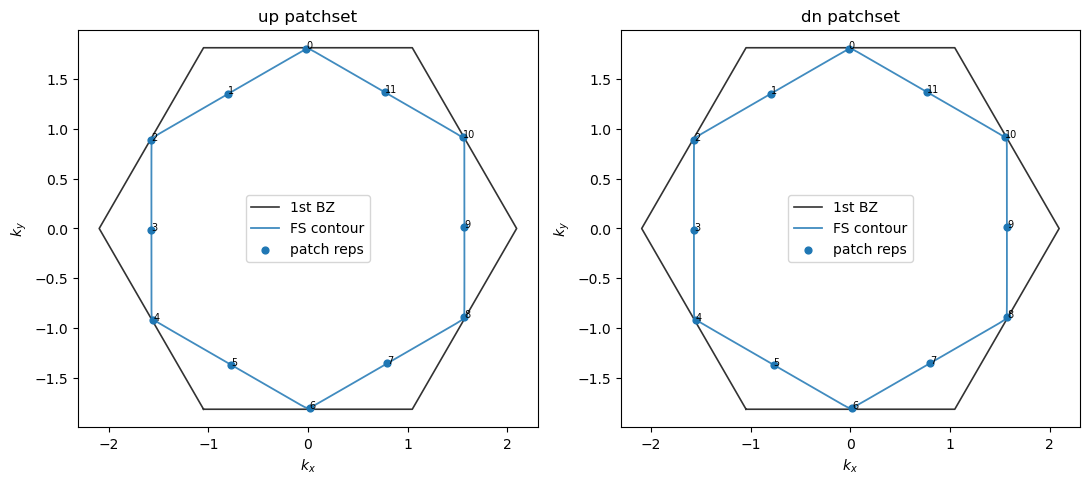

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_patchset(patchsets["up"], ax=axes[0], show_contour=True, show_velocity=False, show_bz=True)
axes[0].set_title("up patchset")
plot_patchset(patchsets["dn"], ax=axes[1], show_contour=True, show_velocity=False, show_bz=True)
axes[1].set_title("dn patchset")
plt.tight_layout()
plt.show()


## 3. Helpers for running a benchmark interaction point

In [7]:

def build_solver(model, patchsets, U, V, flow_kwargs=None):
    flow_kwargs = {} if flow_kwargs is None else dict(flow_kwargs)
    interaction = BareExtendedHubbard.from_kagome_model(model, U=U, V=V)
    bare_gamma = BareVertexFromInteraction(interaction, patchsets)
    solver = FRGFlowSolver(
        patchsets=patchsets,
        bare_gamma=bare_gamma,
        **flow_kwargs,
    )
    return interaction, bare_gamma, solver


def summarize_history(history):
    rows = []
    for rec in history:
        rows.append({
            "step": rec.step_index,
            "T": rec.temperature,
            "channel_norm": rec.channel_norm,
            "rhs_norm": rec.rhs_norm,
            "leading_channel": rec.leading_channel_name,
            "leading_order": rec.leading_order_label,
            "leading_abs_eval": rec.leading_eigenvalue_abs,
            "instability": rec.instability,
            "reason": rec.instability_reason,
        })
    return rows


def pretty_print_final_record(history):
    rec = history[-1]
    print("===== Final record =====")
    pprint(rec.summary_dict())
    return rec


def plot_history(history, title):
    steps = [h.step_index for h in history]
    Ts = [h.temperature for h in history]
    evals = [np.nan if h.leading_eigenvalue_abs is None else h.leading_eigenvalue_abs for h in history]
    norms = [h.channel_norm for h in history]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(steps, evals, marker="o")
    axes[0].set_xlabel("step")
    axes[0].set_ylabel("leading |eigenvalue|")
    axes[0].set_title(f"{title}: leading eigenvalue")

    axes[1].plot(steps, norms, marker="o")
    axes[1].set_xlabel("step")
    axes[1].set_ylabel("channel norm")
    axes[1].set_title(f"{title}: channel norm")

    plt.tight_layout()
    plt.show()


def run_case(case_name, U, V, flow_kwargs=None):
    print(f"\n===== Running case: {case_name} (U={U}, V={V}) =====")
    interaction, bare_gamma, solver = build_solver(
        model=model,
        patchsets=patchsets,
        U=U,
        V=V,
        flow_kwargs=flow_kwargs if flow_kwargs is not None else FLOW_KWARGS,
    )
    history = solver.run()
    print(f"history length = {len(history)}")
    print(f"instability record = {None if solver.instability_record is None else solver.instability_record.step_index}")
    final_rec = pretty_print_final_record(history)
    plot_history(history, case_name)
    return {
        "case_name": case_name,
        "U": U,
        "V": V,
        "interaction": interaction,
        "solver": solver,
        "history": history,
        "final_record": final_rec,
    }



## 4. FM benchmark: `U=6, V=0`

Expectation from the PRL benchmark at van Hove filling:
- dominant onsite interaction should favor **ferromagnetism (FM)**.


In [ ]:

fm_result = run_case("FM benchmark", U=6.0, V=0.0, flow_kwargs=FLOW_KWARGS)



===== Running case: FM benchmark (U=6.0, V=0.0) =====



## 5. PI benchmark: `U=0, V=10`

Expectation from the PRL benchmark at van Hove filling:
- dominant nearest-neighbor repulsion should favor **Pomeranchuk instability (PI)** with d-wave character.

If this still does **not** look PI-like, then the likely next suspects are:
- `form_factor.py`
- `kagome_order_diagnosis.py`


In [ ]:

pi_result = run_case("PI benchmark", U=0.0, V=10.0, flow_kwargs=FLOW_KWARGS)


## 6. Compact side-by-side summary

In [ ]:

def compact_case_summary(result):
    rec = result["final_record"]
    return {
        "case": result["case_name"],
        "U": result["U"],
        "V": result["V"],
        "leading_channel": rec.leading_channel_name,
        "leading_order": rec.leading_order_label,
        "leading_abs_eval": rec.leading_eigenvalue_abs,
        "channel_norm": rec.channel_norm,
        "instability": rec.instability,
        "instability_reason": rec.instability_reason,
    }

summary = [
    compact_case_summary(fm_result),
    compact_case_summary(pi_result),
]

for row in summary:
    pprint(row)



## 7. Optional: inspect the raw diagnosis payloads

This is useful when:
- the FM case is reasonable but the PI case is not
- or the final `leading_order_label` is too coarse / ambiguous


In [ ]:

print("===== FM diagnosis payload =====")
pprint(fm_result["final_record"].diagnosis_payload)

print("\n===== PI diagnosis payload =====")
pprint(pi_result["final_record"].diagnosis_payload)



## 8. What to conclude from the outcomes

### If you get:
- `U=6, V=0` → FM-like
- `U=0, V=10` → PI-like

then the corrected `channels.py` + `frg_flow.py` have likely fixed the main bug, and the whole pipeline is much closer to the target PRL behavior.

### If you get:
- FM benchmark looks reasonable
- PI benchmark still does **not** become PI-like

then the next things to debug are likely:
1. **form-factor projection**
2. **PI degeneracy handling**
3. **kagome-specific diagnosis templates**

and only after that would I go back and seriously suspect the one-loop kernel again.
